# Car Price Predictor Analysis
**Portfolio Project: Linear Regression Modeling**

## Description
This project explores the relationship between various vehicle characteristics and car prices using linear regression. By analyzing engine displacement, mileage, top speed, and maintenance intervals, we aim to statistically identify the strongest predictor of a vehicle's market value. 

## Real World Conclusion
Understanding the most statistically significant predictors of car prices empowers consumers to make informed purchasing decisions and allows dealerships to optimize their pricing models. As shown in the outputs below, the code automatically ranks and determines the strongest driving factor behind vehicle price.

--- Model 1 Assessment ---
Independent Variable: car_engine_displacement
R-squared: 0.0020
P-value: 5.3157e-01
Slope: -60.5566
Intercept: 10113.8495
Prediction for 2.5: $9,962.46
------------------------------



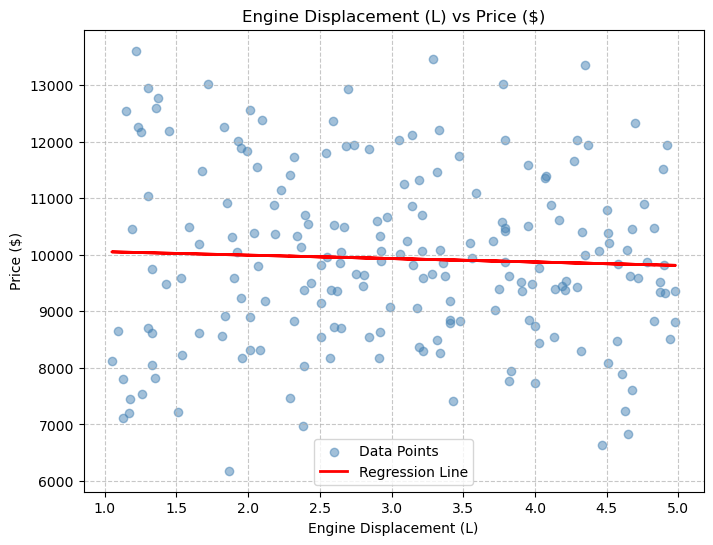

--- Model 2 Assessment ---
Independent Variable: car_mileage
R-squared: 0.1817
P-value: 3.1106e-10
Slope: -0.0115
Intercept: 11139.9594
Prediction for 108567: $9,886.45
------------------------------



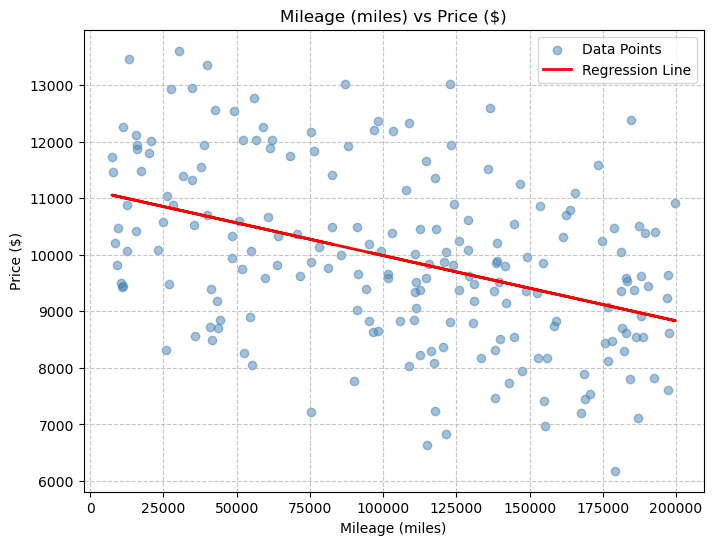

--- Model 3 Assessment ---
Independent Variable: car_top_speed
R-squared: 0.1143
P-value: 9.8228e-07
Slope: 13.8859
Intercept: 7371.7553
Prediction for 189: $9,996.19
------------------------------



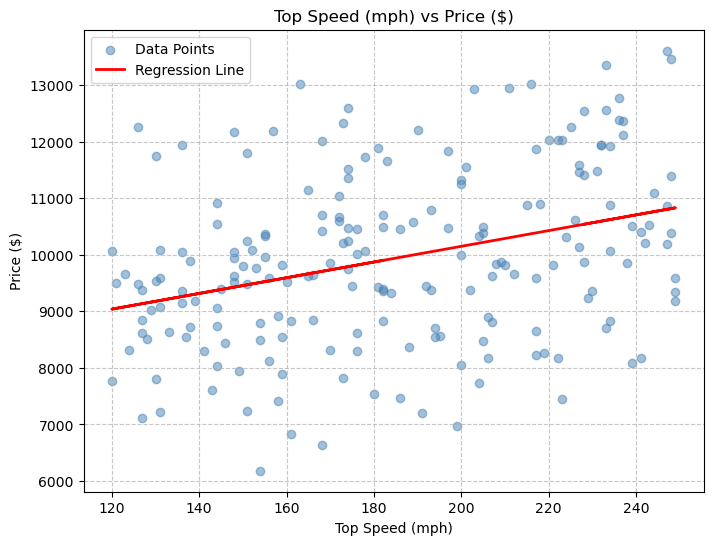

--- Model 4 Assessment ---
Independent Variable: car_maintenance_interval
R-squared: 0.1723
P-value: 9.8954e-10
Slope: 0.0881
Intercept: 8381.3079
Prediction for 15000: $9,702.96
------------------------------



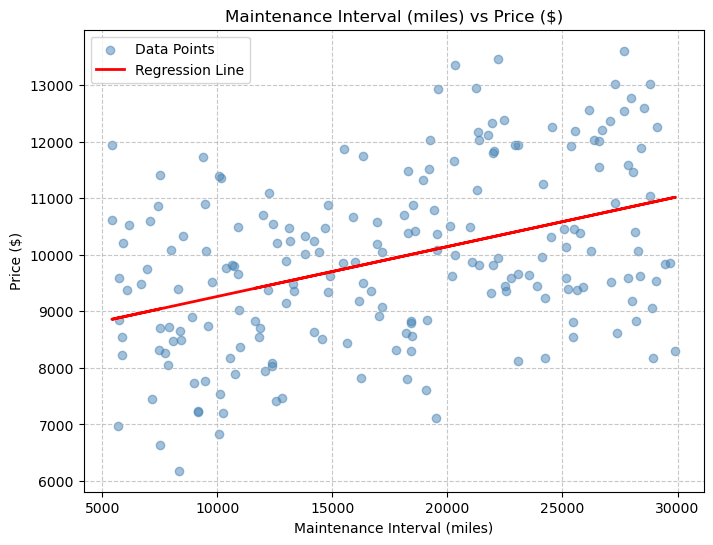

Conclusion: The strongest predictor of car price is 'Mileage' with an R-squared of 0.1817.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
import os

# Create an images directory to keep the repository organized
os.makedirs('images', exist_ok=True)

# Use a relative file path (ensure your CSV is placed in a folder named 'data')
file_path = "data/car_data.csv"

# Try-except block for robust error handling
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
    print("Please ensure you have created a 'data' folder in the same directory as this notebook and placed 'car_data.csv' inside it.")
    raise

def perform_analysis(x_col, y_col, pred_val, model_num, x_label, y_label):
    """
    Performs linear regression analysis, prints statistical outputs,
    and saves a scatter plot with the regression line.
    """
    # Drop rows where either x or y is missing to prevent regression errors
    clean_df = df.dropna(subset=[x_col, y_col])
    x = clean_df[x_col]
    y = clean_df[y_col]
    
    # Calculate linear regression
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    r_squared = r_value ** 2
    
    # Predict the y value for the given x
    prediction = intercept + (slope * pred_val)
    
    # Print assessment output
    print(f"--- Model {model_num} Assessment ---")
    print(f"Independent Variable: {x_col}")
    print(f"R-squared: {r_squared:.4f}")
    print(f"P-value: {p_value:.4e}")
    print(f"Slope: {slope:.4f}")
    print(f"Intercept: {intercept:.4f}")
    print(f"Prediction for {pred_val}: ${prediction:,.2f}")
    print("-" * 30 + "\n")
    
    # Create and format the plot
    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, alpha=0.5, label='Data Points', color='steelblue')
    plt.plot(x, intercept + slope * x, color='red', linewidth=2, label='Regression Line')
    plt.title(f"{x_label} vs {y_label}")
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Save the figure cleanly into the images directory
    plt.savefig(f'images/model_{model_num}.png', bbox_inches='tight')
    plt.show()
    plt.close()
    
    return r_squared

# --- Run Models ---

# 1. Engine Displacement vs Price
r1 = perform_analysis('car_engine_displacement', 'car_price', 2.5, 1, 'Engine Displacement (L)', 'Price ($)')

# 2. Mileage vs Price
r2 = perform_analysis('car_mileage', 'car_price', 108567, 2, 'Mileage (miles)', 'Price ($)')

# 3. Top Speed vs Price
r3 = perform_analysis('car_top_speed', 'car_price', 189, 3, 'Top Speed (mph)', 'Price ($)')

# 4. Maintenance Interval vs Price
r4 = perform_analysis('car_maintenance_interval', 'car_price', 15000, 4, 'Maintenance Interval (miles)', 'Price ($)')

# --- Conclusion Requirement ---

# Find the strongest predictor automatically based on R-squared value
models = {
    "Engine Displacement": r1, 
    "Mileage": r2, 
    "Top Speed": r3, 
    "Maintenance Interval": r4
}

strongest = max(models, key=models.get)
print(f"Conclusion: The strongest predictor of car price is '{strongest}' with an R-squared of {models[strongest]:.4f}.")